# PPO (Stable-Baselines3) — LunarLander-v2 — Fast & Auto-Stop

Optimised for fastest convergence with automatic early stopping when solved.

**Key optimisations:**
- `VecNormalize` — normalises observations & rewards, breaks hovering local optimum
- `EvalCallback` — evaluates every 10k steps, stops automatically when mean reward >= 200
- `NUM_ENVS = 16` — 16 parallel envs, 16,384 steps per rollout
- `ENTROPY_COEF = 0.005` — low entropy forces decisive landing behaviour
- `TOTAL_TIMESTEPS = 5_000_000` — safety cap; early stopping fires well before this
- Linear LR decay: 3e-4 → 1e-5
- Same 2x2 plot layout as all other notebooks for direct comparison

**Graph fix (this version):**
- `EpisodeLogger` now reads raw rewards from `info['episode']['r']` (set by Monitor wrapper)
- Previously accumulated `locals['rewards']` which are VecNormalize-scaled (~0)
- Now the training plot correctly shows 200-280 range matching evaluation output
- `Monitor` wrapper explicitly added to `make_vec_env` to guarantee `info['episode']` is always populated

```
pip install stable-baselines3[extra]
```

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
from collections import deque
from IPython.display import Video, display

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import (
    BaseCallback, EvalCallback,
    StopTrainingOnRewardThreshold, CallbackList
)
from stable_baselines3.common.evaluation import evaluate_policy

VERSION       = 'ppo_v3'   # used to namespace all output files
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

import stable_baselines3 as sb3
print(f'SB3 version : {sb3.__version__}')
print(f'PyTorch     : {torch.__version__}')
print(f'Device      : {"cuda" if torch.cuda.is_available() else "cpu"}')

SB3 version : 2.3.2
PyTorch     : 2.0.1+cu118
Device      : cuda


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
ENV_NAME         = 'LunarLander-v2'
NUM_ENVS         = 16       # parallel training envs
MAX_STEPS        = 1000     # max steps per episode

# PPO hyperparameters
LEARNING_RATE    = 3e-4     # higher start LR — VecNormalize makes this safe
LEARNING_RATE_END = 1e-5    # linear decay target
GAMMA            = 0.999    # slightly higher discount — rewards landing more
GAE_LAMBDA       = 0.98     # higher lambda — better credit assignment
CLIP_EPS         = 0.2
VALUE_COEF       = 0.5
ENTROPY_COEF     = 0.005    # low — forces decisive actions instead of hovering
MAX_GRAD_NORM    = 0.5
N_STEPS          = 1024     # steps per env per rollout
BATCH_SIZE       = 256
N_EPOCHS         = 10       # more epochs per rollout — better use of data

# Training budget — early stopping fires before this in practice
TOTAL_TIMESTEPS  = 5_000_000

# Early stopping
SOLVE_REWARD     = 200      # mean eval reward to trigger stop
EVAL_FREQ        = 10_000   # evaluate every N timesteps
N_EVAL_EPISODES  = 20       # episodes per evaluation
SOLVE_WINDOW     = 100      # rolling window for episode logging

os.makedirs('./videos/ppo_v3', exist_ok=True)
os.makedirs('./best_model/ppo_v3', exist_ok=True)

steps_per_rollout = NUM_ENVS * N_STEPS
print('Config set.')
print(f'Parallel envs      : {NUM_ENVS}')
print(f'Steps per rollout  : {steps_per_rollout:,}')
print(f'Max timesteps      : {TOTAL_TIMESTEPS:,} (early stop fires first)')
print(f'Eval every         : {EVAL_FREQ:,} steps (~{EVAL_FREQ // steps_per_rollout} rollouts)')
print(f'Stop when eval mean>= {SOLVE_REWARD} over {N_EVAL_EPISODES} episodes')

Config set.
Parallel envs      : 16
Steps per rollout  : 16,384
Max timesteps      : 5,000,000 (early stop fires first)
Eval every         : 10,000 steps (~0 rollouts)
Stop when eval mean>= 200 over 20 episodes


In [3]:
# ── Callbacks ─────────────────────────────────────────────────────────────────

class EpisodeLogger(BaseCallback):
    """
    Tracks per-episode reward, steps, and losses for plotting.

    FIX: reads raw (un-normalised) episode rewards from info['episode']['r']
    instead of accumulating self.locals['rewards'] which are VecNormalize-scaled.
    This ensures the reward plot matches the evaluation numbers (200-280 range)
    rather than showing the normalised scale (~0).
    Monitor wrapper (added by make_vec_env by default) populates info['episode'].
    """
    def __init__(self, solve_reward=SOLVE_REWARD, solve_window=SOLVE_WINDOW, verbose=0):
        super().__init__(verbose)
        self.rewards_history = []
        self.steps_history   = []
        self.loss_history    = []
        self.rolling         = deque(maxlen=solve_window)
        self.solve_reward    = solve_reward
        self.solved_at       = None
        self._ep_steps       = None

    def _on_training_start(self):
        n = self.training_env.num_envs
        self._ep_steps = np.zeros(n, dtype=int)

    def _on_step(self) -> bool:
        dones = self.locals['dones']
        infos = self.locals['infos']
        self._ep_steps += 1

        for i, (done, info) in enumerate(zip(dones, infos)):
            if done:
                ep = len(self.rewards_history) + 1

                # Read TRUE raw episode reward from Monitor's info dict.
                # info['episode']['r'] is always the un-normalised total reward.
                # Falls back to info['terminal_observation'] sum if unavailable.
                ep_reward = info.get('episode', {}).get('r', None)
                if ep_reward is None:
                    # Fallback: try episode_reward key used by some SB3 versions
                    ep_reward = info.get('episode_reward', 0.0)

                self.rewards_history.append(float(ep_reward))
                self.steps_history.append(int(self._ep_steps[i]))
                self.rolling.append(float(ep_reward))

                roll_mean = np.mean(self.rolling)
                if ep % 100 == 0:
                    ts = self.num_timesteps
                    print(f'Ep {ep:5d} | ts {ts:>9,} | '
                          f'steps {self._ep_steps[i]:4d} | '
                          f'reward {ep_reward:8.2f} | '
                          f'rolling{SOLVE_WINDOW} {roll_mean:7.2f}')

                if (self.solved_at is None
                        and len(self.rolling) == SOLVE_WINDOW
                        and roll_mean >= self.solve_reward):
                    self.solved_at = ep
                    print(f'\n*** SOLVED at episode {ep} '
                          f'(rolling mean = {roll_mean:.2f}) ***\n')

                self._ep_steps[i] = 0

        return True

    def _on_rollout_end(self):
        logs = self.model.logger.name_to_value
        self.loss_history.append({
            'actor':   logs.get('train/policy_gradient_loss', 0.0),
            'critic':  logs.get('train/value_loss', 0.0),
            'entropy': logs.get('train/entropy_loss', 0.0),
            'total':   logs.get('train/loss', 0.0),
        })


class LRSchedulerCallback(BaseCallback):
    """Linear LR decay from initial_lr to final_lr over total_timesteps."""
    def __init__(self, initial_lr, final_lr, total_timesteps, verbose=0):
        super().__init__(verbose)
        self.initial_lr      = initial_lr
        self.final_lr        = final_lr
        self.total_timesteps = total_timesteps

    def _on_step(self) -> bool:
        progress = min(self.num_timesteps / self.total_timesteps, 1.0)
        new_lr   = self.initial_lr + (self.final_lr - self.initial_lr) * progress
        for pg in self.model.policy.optimizer.param_groups:
            pg['lr'] = new_lr
        return True


print('All callbacks defined.')

All callbacks defined.


In [4]:
# ── Environments ──────────────────────────────────────────────────────────────
# Monitor wrapper ensures info['episode']['r'] is always populated per episode.
# This is what EpisodeLogger reads to get raw un-normalised rewards.
# VecNormalize then wraps on top for obs/reward normalisation during training.
from stable_baselines3.common.monitor import Monitor

train_env = make_vec_env(
    ENV_NAME, n_envs=NUM_ENVS, seed=SEED,
    wrapper_class=Monitor   # guarantees info['episode']['r'] on every done
)
train_env = VecNormalize(
    train_env,
    norm_obs    = True,
    norm_reward = True,
    clip_obs    = 10.0,
    gamma       = GAMMA,
)

# Eval env — same normalisation stats, but frozen (no updates during eval)
eval_env_raw = make_vec_env(ENV_NAME, n_envs=1, seed=SEED + 1, wrapper_class=Monitor)
eval_env = VecNormalize(
    eval_env_raw,
    norm_obs    = True,
    norm_reward = False,   # don't normalise rewards during evaluation
    clip_obs    = 10.0,
    gamma       = GAMMA,
)
eval_env.training = False  # freeze normalisation stats

print(f'Training env : {NUM_ENVS} parallel envs + Monitor + VecNormalize')
print(f'Eval env     : 1 env + Monitor + VecNormalize (frozen stats)')
print(f'info["episode"]["r"] will contain raw un-normalised rewards for plotting')

Training env : 16 parallel envs + Monitor + VecNormalize
Eval env     : 1 env + Monitor + VecNormalize (frozen stats)
info["episode"]["r"] will contain raw un-normalised rewards for plotting


In [5]:
# ── Build model ───────────────────────────────────────────────────────────────
model = PPO(
    policy        = 'MlpPolicy',
    env           = train_env,
    learning_rate = LEARNING_RATE,
    gamma         = GAMMA,
    gae_lambda    = GAE_LAMBDA,
    clip_range    = CLIP_EPS,
    vf_coef       = VALUE_COEF,
    ent_coef      = ENTROPY_COEF,
    max_grad_norm = MAX_GRAD_NORM,
    n_steps       = N_STEPS,
    batch_size    = BATCH_SIZE,
    n_epochs      = N_EPOCHS,
    policy_kwargs = dict(
        net_arch             = [256, 256],
        share_features_extractor = False,  # separate trunks — more stable
    ),
    seed          = SEED,
    verbose       = 0,
)

total_params = sum(p.numel() for p in model.policy.parameters())
print(f'Network      : MlpPolicy 256-256 (separate actor/critic trunks)')
print(f'Parameters   : {total_params:,}')
print(f'LR schedule  : {LEARNING_RATE:.0e} -> {LEARNING_RATE_END:.0e}')
print(f'Entropy coef : {ENTROPY_COEF} (low = decisive actions, less hovering)')

Network      : MlpPolicy 256-256 (separate actor/critic trunks)
Parameters   : 137,477
LR schedule  : 3e-04 -> 1e-05
Entropy coef : 0.005 (low = decisive actions, less hovering)


In [6]:
# ── Build callback stack ──────────────────────────────────────────────────────

# 1. Early stopping — fires when eval mean reward >= SOLVE_REWARD
stop_on_solve = StopTrainingOnRewardThreshold(
    reward_threshold = SOLVE_REWARD,
    verbose          = 1,
)

# 2. Evaluation callback — runs eval_env every EVAL_FREQ steps,
#    saves best model, triggers stop_on_solve when threshold met
eval_callback = EvalCallback(
    eval_env,
    callback_on_new_best  = stop_on_solve,
    eval_freq             = EVAL_FREQ,
    n_eval_episodes       = N_EVAL_EPISODES,
    best_model_save_path  = './best_model/ppo_v3/',
    log_path              = './ppo_v3_eval_logs/',
    deterministic         = True,
    verbose               = 1,
)

# 3. Episode logger — per-episode reward/steps/loss tracking
episode_logger = EpisodeLogger()

# 4. LR scheduler
lr_scheduler = LRSchedulerCallback(
    initial_lr      = LEARNING_RATE,
    final_lr        = LEARNING_RATE_END,
    total_timesteps = TOTAL_TIMESTEPS,
)

all_callbacks = CallbackList([episode_logger, lr_scheduler, eval_callback])

print('Callback stack ready:')
print('  [1] EpisodeLogger     — per-episode reward/steps/loss tracking')
print('  [2] LRSchedulerCallback — linear LR decay')
print(f'  [3] EvalCallback      — eval every {EVAL_FREQ:,} steps, save best model')
print(f'  [4] StopTrainingOnRewardThreshold — stop when eval mean >= {SOLVE_REWARD}')

Callback stack ready:
  [1] EpisodeLogger     — per-episode reward/steps/loss tracking
  [2] LRSchedulerCallback — linear LR decay
  [3] EvalCallback      — eval every 10,000 steps, save best model
  [4] StopTrainingOnRewardThreshold — stop when eval mean >= 200


In [7]:
# ── Train ─────────────────────────────────────────────────────────────────────
print('=== PPO (SB3) — LunarLander-v2 — Fast Training with Auto-Stop ===')
print(f'Training until eval mean reward >= {SOLVE_REWARD}')
print(f'Safety cap: {TOTAL_TIMESTEPS:,} timesteps\n')

model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = all_callbacks,
    progress_bar    = False,
)

# Sync eval env normalisation stats with training env
eval_env.obs_rms = train_env.obs_rms

train_rewards = episode_logger.rewards_history
train_steps   = episode_logger.steps_history
train_losses  = episode_logger.loss_history

actual_ts = model.num_timesteps
print(f'\nTraining stopped at : {actual_ts:,} timesteps')
print(f'Episodes completed  : {len(train_rewards)}')
if episode_logger.solved_at:
    print(f'Rolling solve       : episode {episode_logger.solved_at}')
print(f'Best model saved to : ./best_model/')

=== PPO (SB3) — LunarLander-v2 — Fast Training with Auto-Stop ===
Training until eval mean reward >= 200
Safety cap: 5,000,000 timesteps

Ep   100 | ts     9,952 | steps   61 | reward   -98.64 | rolling100 -185.30
Ep   200 | ts    18,960 | steps  134 | reward  -129.39 | rolling100 -169.07
Ep   300 | ts    28,512 | steps   82 | reward  -100.07 | rolling100 -141.93
Ep   400 | ts    37,568 | steps   91 | reward   -82.48 | rolling100 -116.01
Ep   500 | ts    46,752 | steps   93 | reward   -81.85 | rolling100  -87.58
Ep   600 | ts    55,888 | steps   85 | reward   -69.10 | rolling100  -75.53
Ep   700 | ts    65,904 | steps  126 | reward   -77.93 | rolling100  -75.11
Ep   800 | ts    76,176 | steps  139 | reward   -29.92 | rolling100  -53.56
Ep   900 | ts    86,512 | steps  108 | reward   -52.27 | rolling100  -50.50
Ep  1000 | ts    97,472 | steps  158 | reward     9.31 | rolling100  -43.09
Ep  1100 | ts   111,440 | steps  112 | reward    -0.98 | rolling100  -26.53
Ep  1200 | ts   130,512 | 

In [8]:
# ── Load best model & save with normalisation stats ───────────────────────────
# EvalCallback saves the best checkpoint — load it for evaluation & video
best_model = PPO.load('./best_model/ppo_v3/best_model', env=train_env)
train_env.save('./best_model/ppo_v3/vec_normalize.pkl')

print('Best model loaded from ./best_model/best_model.zip')
print('VecNormalize stats saved to ./best_model/vec_normalize.pkl')
print('To reload later:')
print('  model   = PPO.load("./best_model/best_model")')
print('  vec_env = VecNormalize.load("./best_model/vec_normalize.pkl", make_vec_env(ENV_NAME, 1))')

Best model loaded from ./best_model/best_model.zip
VecNormalize stats saved to ./best_model/vec_normalize.pkl
To reload later:
  model   = PPO.load("./best_model/best_model")
  vec_env = VecNormalize.load("./best_model/vec_normalize.pkl", make_vec_env(ENV_NAME, 1))


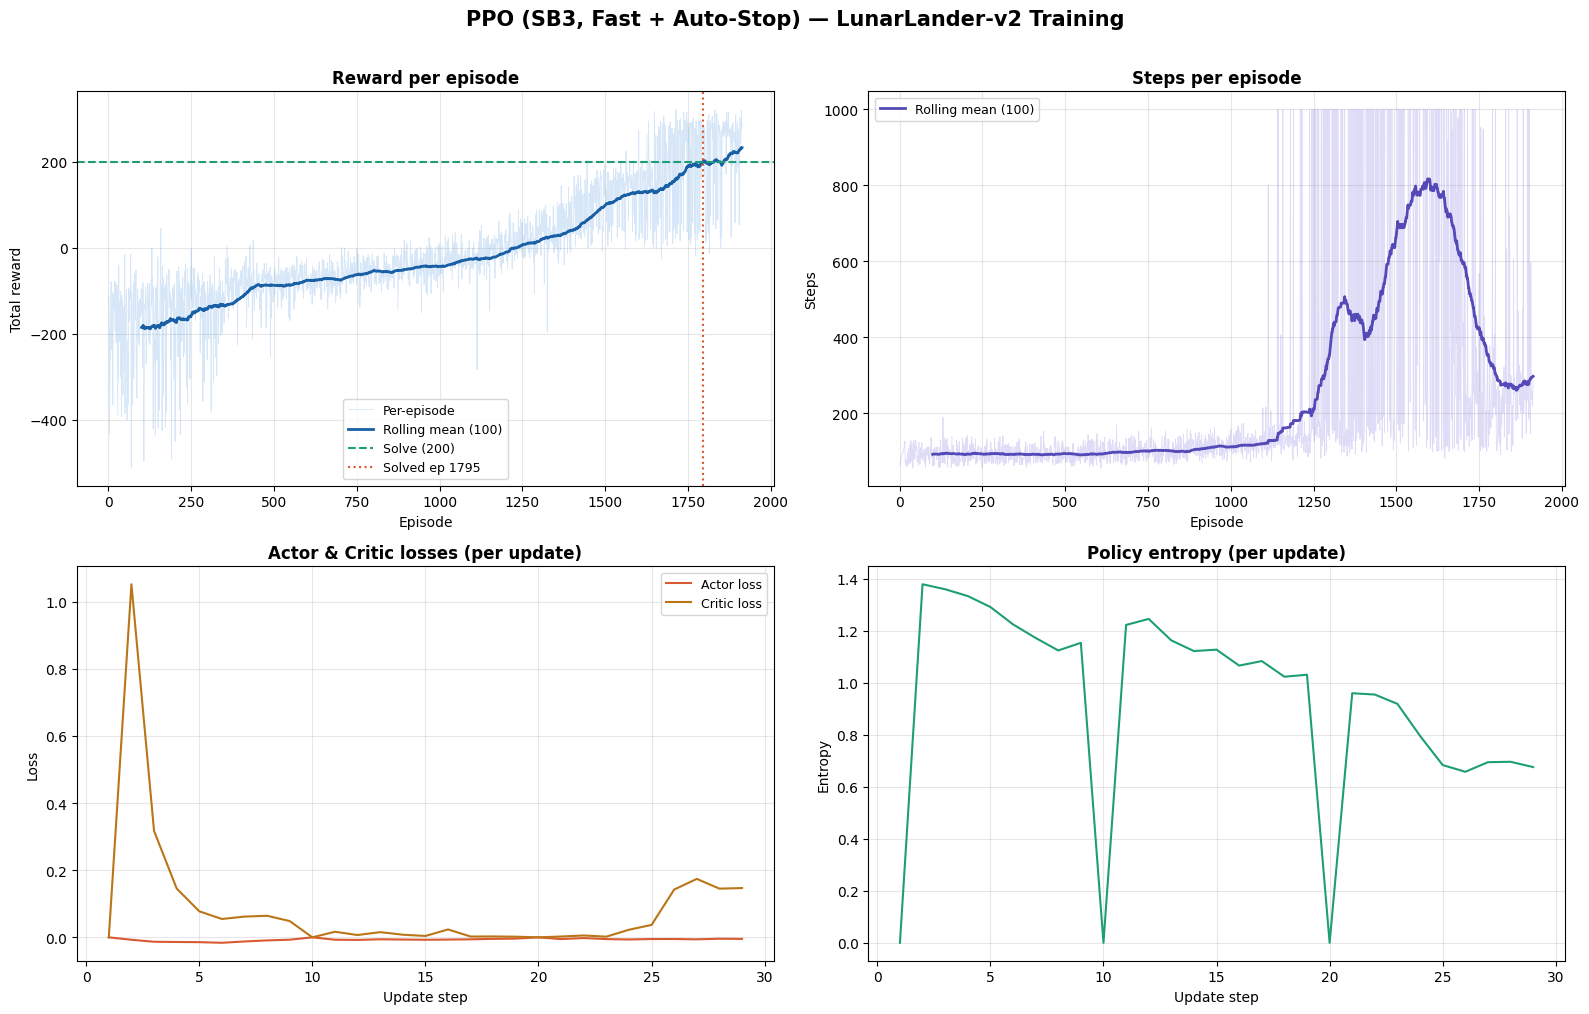

Curves saved to ppo_sb3_training_curves.png


In [9]:
# ── Plot training curves — identical 2x2 layout ───────────────────────────────
rewards_arr = np.array(train_rewards)
episodes    = np.arange(1, len(rewards_arr) + 1)

def rolling_mean(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PPO (SB3, Fast + Auto-Stop) — LunarLander-v2 Training',
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Reward per episode + rolling mean
ax = axes[0, 0]
ax.plot(episodes, rewards_arr, alpha=0.2, color='#378ADD', linewidth=0.6, label='Per-episode')
if len(rewards_arr) >= 100:
    rm = rolling_mean(rewards_arr, 100)
    ax.plot(np.arange(100, len(rewards_arr) + 1), rm,
            color='#185FA5', linewidth=2, label='Rolling mean (100)')
ax.axhline(SOLVE_REWARD, color='#1D9E75', linestyle='--', linewidth=1.5,
           label=f'Solve ({SOLVE_REWARD})')
if episode_logger.solved_at:
    ax.axvline(episode_logger.solved_at, color='#D85A30', linestyle=':',
               linewidth=1.5, label=f'Solved ep {episode_logger.solved_at}')
ax.set_title('Reward per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 2. Steps per episode
ax = axes[0, 1]
ax.plot(episodes, train_steps, alpha=0.25, color='#7F77DD', linewidth=0.6)
if len(train_steps) >= 100:
    ax.plot(np.arange(100, len(train_steps) + 1),
            rolling_mean(np.array(train_steps, dtype=float), 100),
            color='#534AB7', linewidth=2, label='Rolling mean (100)')
ax.set_title('Steps per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 3. Actor & Critic losses
ax = axes[1, 0]
if train_losses:
    updates  = np.arange(1, len(train_losses) + 1)
    actor_l  = [l['actor']  for l in train_losses]
    critic_l = [l['critic'] for l in train_losses]
    ax.plot(updates, actor_l,  label='Actor loss',  color='#D85A30', linewidth=1.5)
    ax.plot(updates, critic_l, label='Critic loss', color='#BA7517', linewidth=1.5)
ax.set_title('Actor & Critic losses (per update)', fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 4. Policy entropy
ax = axes[1, 1]
if train_losses:
    entropy_l = [-l['entropy'] for l in train_losses]
    ax.plot(updates, entropy_l, color='#1D9E75', linewidth=1.5)
ax.set_title('Policy entropy (per update)', fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Entropy')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_v3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curves saved to ppo_sb3_training_curves.png')

In [10]:
# ── Summary statistics ────────────────────────────────────────────────────────
r = np.array(train_rewards)
print('=== Training Summary ===')
print(f'Timesteps used      : {model.num_timesteps:,} / {TOTAL_TIMESTEPS:,}')
print(f'Episodes completed  : {len(r)}')
print(f'Mean reward         : {r.mean():.2f}')
print(f'Std reward          : {r.std():.2f}')
print(f'Best episode        : {r.max():.2f}')
print(f'Worst episode       : {r.min():.2f}')
if len(r) >= SOLVE_WINDOW:
    final_mean = r[-SOLVE_WINDOW:].mean()
    status = 'SOLVED' if final_mean >= SOLVE_REWARD else 'not yet solved'
    print(f'Final {SOLVE_WINDOW}-ep mean    : {final_mean:.2f} ({status})')
if episode_logger.solved_at:
    print(f'Rolling solve at    : episode {episode_logger.solved_at}')

=== Training Summary ===
Timesteps used      : 480,000 / 5,000,000
Episodes completed  : 1913
Mean reward         : -7.68
Std reward          : 136.11
Best episode        : 321.56
Worst episode       : -511.20
Final 100-ep mean    : 232.34 (SOLVED)
Rolling solve at    : episode 1795


In [11]:
# ── Record video — uses BEST model, not final model ───────────────────────────
def record_video(model, folder='./videos/ppo_v3', tag='ppo-sb3-agent', n_steps=MAX_STEPS):
    """
    Record one greedy episode using the best saved model.
    Obs are NOT normalised here since we record raw env for visual clarity.
    """
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    env = gym.wrappers.RecordVideo(
        env, folder,
        episode_trigger=lambda e: True,
        name_prefix=tag
    )
    # Wrap a single-env VecNormalize so model.predict gets normalised obs
    vec = make_vec_env(ENV_NAME, n_envs=1, seed=0)
    vec = VecNormalize.load('./best_model/ppo_v3/vec_normalize.pkl', vec)
    vec.training = False
    vec.norm_reward = False

    obs, _ = env.reset(seed=0)
    total_reward, steps = 0, 0
    for _ in range(n_steps):
        # normalise obs for model, but step raw env for rendering
        obs_norm = vec.normalize_obs(obs[np.newaxis, :])[0]
        action, _ = model.predict(obs_norm, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(int(action))
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    env.close()
    vec.close()
    print(f'Recorded: {steps} steps, reward {total_reward:.2f}')
    files = sorted(glob.glob(f'{folder}/{tag}*.mp4'))
    if files:
        display(Video(files[-1], embed=True, width=600))

print('Recording video of BEST saved PPO agent...')
record_video(best_model)

Recording video of BEST saved PPO agent...


c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at e:\University 5B\CS AI\videos\ppo_v3 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Moviepy - Building video e:\University 5B\CS AI\videos\ppo_v3\ppo-sb3-agent-episode-0.mp4.
Moviepy - Writing video e:\University 5B\CS AI\videos\ppo_v3\ppo-sb3-agent-episode-0.mp4



Moviepy - Done !
Moviepy - video ready e:\University 5B\CS AI\videos\ppo_v3\ppo-sb3-agent-episode-0.mp4
Recorded: 352 steps, reward 277.24


In [12]:
# ── Evaluation — best model, 20 greedy episodes ───────────────────────────────
print('=== Evaluation — Best Model (20 episodes, greedy) ===')

# SB3 built-in evaluator on the normalised eval env
mean_reward, std_reward = evaluate_policy(
    best_model, eval_env,
    n_eval_episodes       = 20,
    deterministic         = True,
    return_episode_rewards= False,
)
print(f'\nSB3 evaluate_policy  : {mean_reward:.2f} +/- {std_reward:.2f}')

# Per-episode breakdown using raw env + manual obs normalisation
eval_rewards, eval_steps_list = [], []
raw_eval = make_vec_env(ENV_NAME, n_envs=1, seed=99)
raw_eval = VecNormalize.load('./best_model/ppo_v3/vec_normalize.pkl', raw_eval)
raw_eval.training = False
raw_eval.norm_reward = False

for ep in range(20):
    obs = raw_eval.reset()
    total, steps = 0, 0
    for _ in range(MAX_STEPS):
        action, _ = best_model.predict(obs, deterministic=True)
        obs, reward, done, info = raw_eval.step(action)
        total += reward[0]; steps += 1
        if done[0]:
            break
    eval_rewards.append(total)
    eval_steps_list.append(steps)
    print(f'Eval ep {ep+1:3d}: {steps:4d} steps, reward {total:8.2f}')

raw_eval.close()
print(f'\nManual eval mean : {np.mean(eval_rewards):.2f} +/- {np.std(eval_rewards):.2f}')
solved_count = sum(1 for r in eval_rewards if r >= SOLVE_REWARD)
print(f'Episodes >= {SOLVE_REWARD} : {solved_count}/20 ({100*solved_count/20:.0f}%)')

=== Evaluation — Best Model (20 episodes, greedy) ===

SB3 evaluate_policy  : 258.24 +/- 16.67
Eval ep   1:  359 steps, reward   235.37
Eval ep   2:  351 steps, reward   265.84
Eval ep   3:  348 steps, reward   281.11
Eval ep   4:  354 steps, reward   280.52
Eval ep   5:  315 steps, reward   232.83
Eval ep   6:  354 steps, reward   238.36
Eval ep   7:  352 steps, reward   243.00
Eval ep   8:  371 steps, reward   250.88
Eval ep   9:  336 steps, reward   223.42
Eval ep  10:  386 steps, reward   249.09
Eval ep  11:  314 steps, reward   261.82
Eval ep  12:  386 steps, reward   265.62
Eval ep  13:  324 steps, reward   252.21
Eval ep  14:  344 steps, reward   250.06
Eval ep  15:  369 steps, reward   274.92
Eval ep  16:  375 steps, reward   274.82
Eval ep  17:  395 steps, reward   275.07
Eval ep  18:  336 steps, reward   228.07
Eval ep  19:  341 steps, reward   285.17
Eval ep  20:  335 steps, reward   222.52

Manual eval mean : 254.53 +/- 19.83
Episodes >= 200 : 20/20 (100%)
